 # Cluster of spheres: optimizing scattering ratio

 This example demonstrates how to optimize the positions and radii of a small
 cluster of dielectric spheres.
 The goal is to maximize the ratio of forward to backward scattered intensity
 for a plane-wave excitation. The calculation is performed with `dreams`, while `jax` provides
automatic differentiation and `nlopt` is used for constrained optimization.



In [1]:
import jax.numpy as np
import numpy as anp
import matplotlib.pyplot as plt
import nlopt
import scipy
import scipy.io
import h5py
import treams
import jax
from jax import value_and_grad, grad, jit
from jax.test_util import check_grads
from dreams.jax_tmat import tmats_interact, tmats_no_int
from dreams.jax_op import _sw_pw_expand
from dreams.jax_misc import defaultmodes
from dreams.jax_waves import efield
from treams._core import SphericalWaveBasis as SWB
from matplotlib.patches import Circle


## Defining constraints

To avoid unphysical geometries during optimization, we require that the spheres
do not overlap. The constraints must be differentiable. A valid configuration corresponds to negative constraint values, while positive values indicate a constraint violation.

In [2]:

def overlap(pos, radii):
    d = pos[:, None, :] - pos
    rd = radii[:, None] + radii
    nonzero = np.triu_indices(len(pos), k=1)
    dmat = np.linalg.norm(d[nonzero], axis=-1)
    rd = rd[np.triu_indices(len(radii), k=1)]
    answer = np.max(
        rd - dmat
    ) 
    return answer


def nlopt_constraint(params, gd):
    v, g = value_and_grad(
        lambda params: overlap(params[: 3 * len(params) //4].reshape(-1, 3), params[3 * len(params) //4 :])
    )(params)
    if gd.size > 0:
        gd[:] = g.flatten()
    return v.item()


## The objective

Our objective is the ratio of the scattered power in the forward direction to the sum of the scattered powers in the forward and backward directions, and is therefore bounded between 0 and 1. For a given geometry, we compute the interacting T-matrix, expand the
incident plane wave in the spherical-wave basis, and evaluate the scattered field
at the two observation points.

In [4]:
def func(params):
    """
    Calculate the ratio of intensity in the far field in forward and backward direction (0 and 180 degrees).
    The computation is performed using local basis.
    """
    radii = params[int(len(params) * 3 / 4) :]
    positions = params[: int(len(params) * 3 / 4)].reshape((-1, 3))
    modes = defaultmodes(lmax, num)
    ts = tmats_no_int(radii, epsilons, lmax, k0, helicity)
    tm = tmats_interact(ts, positions, modes, k0, helicity, eps_emb)
    inc = treams.plane_wave([0, 0, Sgn*k0], pol, k0=k0, material=eps_emb)
    plane_basis = inc.basis
    pidx, l, m, pols = defaultmodes(lmax, nmax=num)
    modetype = "regular" 
    inc_expand = _sw_pw_expand(plane_basis, pidx, l, m, pols, positions, k0, eps_emb, poltype, modetype = modetype)  @ np.array(inc)
    sca_dr = tm @ inc_expand    
    efl_fdr = efield(point, pidx, l, m, pols, positions, k0, eps_emb,  modetype="singular", poltype=poltype)
    fld_f = np.array(efl_fdr @ sca_dr)
    efl_bdr = efield(-point, pidx, l, m, pols, positions, k0, eps_emb, modetype="singular", poltype=poltype)
    fld_b = np.array(efl_bdr @ sca_dr)
    f =  np.sum(np.abs(fld_f) ** 2) 
    b = np.sum(np.abs(fld_b) ** 2)
    ans = f/(f+b)
    return ans



def func_treams(params):
    materials = [treams.Material(eps_obj), treams.Material(eps_emb)]
    radii = params[int(len(params) * 3 / 4) :]
    positions = params[: int(len(params) * 3 / 4)].reshape((-1, 3))
    tms = [treams.TMatrix.sphere(lmax, k0, radius, materials) for radius in radii ]
    tm = treams.TMatrix.cluster(tms, positions).interaction.solve()
    inc = treams.plane_wave([0, 0, Sgn*k0], pol, k0=tm.k0, material=tm.material)
    sca_tr = tm @ inc.expand(tm.basis)
    f =  anp.sum(anp.abs(sca_tr.efield(point)) ** 2)
    b =  anp.sum(anp.abs(sca_tr.efield(-point)) ** 2)
    return f/(f+b)

# Optimizer

We now wrap the objective and constraints in an `nlopt` optimizer. The optimization is performed with the MMA algorithm (Method of Moving Asymptotes), a gradient-based method for constrained nonlinear problems. In this step, we set up the constrained maximization, define the inequality constraint, and impose lower bounds on the radii. We also store the objective values and parameter vectors at each step for later analysis.

In [5]:

def optimizer(p, n_steps, verbose=True):
    it = 0
    opt = nlopt.opt(
        nlopt.LD_MMA, p.flatten().shape[0]
    )  
    v_g = jax.jit(value_and_grad(func))
    def nlopt_objective(params, gd):
        nonlocal it
        it += 1
        v, g = v_g(params)
        if gd.size > 0:
            gd[:] = g.ravel()
        v = anp.array(v)
        va.append(v)
        pas.append(params)
        if verbose and (it == 1 or it % 10 == 0 or it == n_steps):
            print(f"[iter {it:4d}] f = {float(v):.6e}")
        return v.item()
    opt.set_max_objective(
        nlopt_objective
    )  # or opt.set_min_objective() for minimization
    opt.add_inequality_constraint(nlopt_constraint, 1e-8)
    bound=[-float('inf')]*p.shape[0]
    ln = p.shape[0]//4
    bound[3*p.shape[0]//4:] = [rl]*ln # set minimum value of radii 
    opt.set_lower_bounds(bound)
    opt.set_maxeval(
        n_steps
    )  
    p_opt = opt.optimize(p)
    pas.append(p_opt)


## Optimization setup

We first define the setup of the scattering problem, and the optimization parameters.


In [20]:
helicity = False
if helicity:
    poltype = "helicity"
else:
    poltype = "parity"
treams.config.POLTYPE = poltype

num = 3
wl1 = 800.
k0 = 2*np.pi/wl1
eps_emb = 1
eps_obj = 2.5**2
epsilons = np.tile(np.array([eps_obj, eps_emb]), (num, 1))
lmax = 4

# Field calculation parameters
r = 10000 # distance to the point of interest
point = anp.array([0., 0., r])#[:, None]
pol = [0, 1, 0] # y-polarization
Sgn = 1 # direction of light propagation

# Optimization settings
index = 0
n_steps = 50
rl = 2. # minimal radius permitted 



We also specify the initial geometry of the cluster. The three spheres are placed on a ring in the xy-plane with equal initial radii. 

In [21]:
radius = 80
R = 150.
ni = np.linspace(0, 360., num + 1)[:-1]
x = R * np.cos(ni*np.pi/180)
y = R * np.sin(ni*np.pi/180)
z  = np.zeros_like(x)
positions = np.array([x, y, z]).T
radii = np.ones(num)*radius
pos = positions.flatten()

print("INITIAL OVERLAP", overlap(positions, radii))


INITIAL OVERLAP -99.80762113533154


We set up both radii and positions as parameters, and compare the output of `dreams` function with `treams` analogue. 

In [22]:

param = np.append(pos, radii) # optimize both positions and radii
treams_obj = func_treams(param)
dreams_obj = func(param)
print("CLOSE INITIAL", np.isclose(dreams_obj, treams_obj))


CLOSE INITIAL True


## Optimization 
Finally, we run the optimization, and compare the final result with `treams` implementation.

In [27]:
va = []
pas = []
optimizer(param, n_steps)
v = func(pas[-1])
treams_obj = func_treams(pas[-1])
print("CLOSE FINAL", v, treams_obj, np.isclose(v, treams_obj))
va.append(v)

[iter    1] f = 6.479265e-01
[iter   10] f = 6.948125e-01
[iter   20] f = 9.934653e-01
[iter   30] f = 9.961991e-01
[iter   40] f = 9.997138e-01
[iter   50] f = 9.999991e-01
CLOSE FINAL 0.9999991406882023 0.9999991406882023 True


# Postprocessing

We plot the final arrangement and the optimization curve. We store the results in an hdf5 file.

FINAL OVERLAP -31.198053548276675
FINAL RADII [132.06588628 135.43639895 135.43639895]


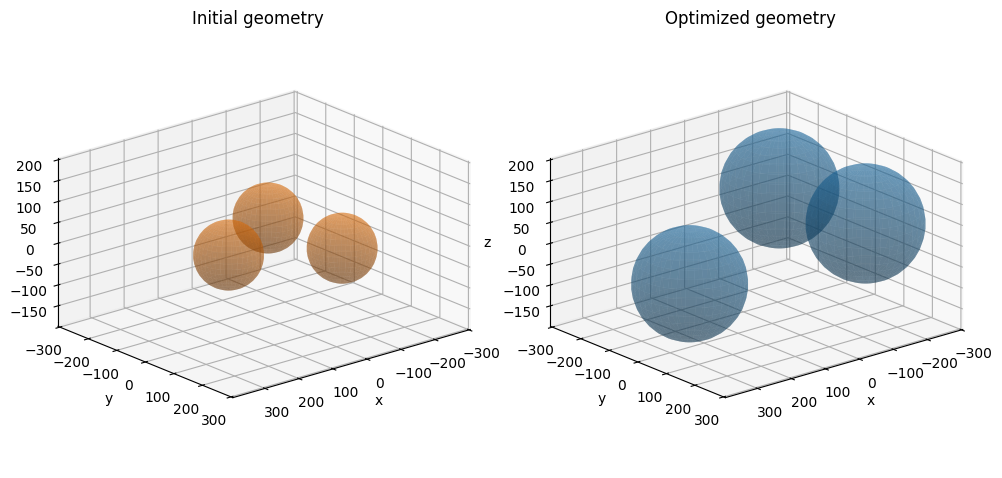

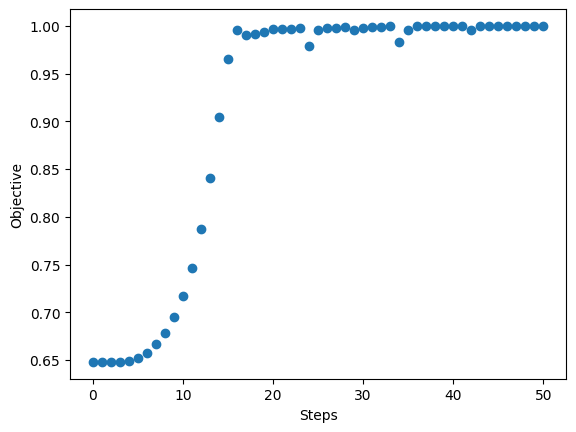

In [30]:
def _set_equal_3d(ax, xlim, ylim, zlim):
    xr = xlim[1] - xlim[0]
    yr = ylim[1] - ylim[0]
    zr = zlim[1] - zlim[0]
    ax.set_box_aspect((xr, yr, zr))
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_zlim(zlim)

def _sphere_mesh(center, radius, nu=40, nv=20):
    u = anp.linspace(0, 2 * anp.pi, nu)
    v = anp.linspace(0, anp.pi, nv)
    x = radius * anp.outer(anp.cos(u), anp.sin(v)) + center[0]
    y = radius * anp.outer(anp.sin(u), anp.sin(v)) + center[1]
    z = radius * anp.outer(anp.ones_like(u), anp.cos(v)) + center[2]
    return x, y, z

def plot_spheres_3d(ax, centers, radii, color="C0", alpha=0.4, title=None):
    centers = anp.asarray(centers, dtype=float)
    radii = anp.asarray(radii, dtype=float)

    for i, (c, r) in enumerate(zip(centers, radii)):
        x, y, z = _sphere_mesh(c, r)
        ax.plot_surface(x, y, z, color=color, alpha=alpha, linewidth=0, shade=True)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title is not None:
        ax.set_title(title)

def plot_initial_final_3d(pos0, rad0, pos1, rad1, elev=20, azim=50):
    pos0 = anp.asarray(pos0, dtype=float)
    rad0 = anp.asarray(rad0, dtype=float)
    pos1 = anp.asarray(pos1, dtype=float)
    rad1 = anp.asarray(rad1, dtype=float)

    all_pos = anp.vstack([pos0, pos1])
    all_rad = anp.concatenate([rad0, rad1])

    xlim = (
        float(anp.min(all_pos[:, 0] - all_rad)) - 20,
        float(anp.max(all_pos[:, 0] + all_rad)) + 20,
    )
    ylim = (
        float(anp.min(all_pos[:, 1] - all_rad)) - 20,
        float(anp.max(all_pos[:, 1] + all_rad)) + 20,
    )
    zlim = (
        float(anp.min(all_pos[:, 2] - all_rad)) - 20,
        float(anp.max(all_pos[:, 2] + all_rad)) + 20,
    )

    fig = plt.figure(figsize=(10, 4.8))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    plot_spheres_3d(ax1, pos0, rad0, color="C1", title="Initial geometry")
    plot_spheres_3d(ax2, pos1, rad1, color="C0", title="Optimized geometry")

    for ax in (ax1, ax2):
        _set_equal_3d(ax, xlim, ylim, zlim)
        ax.view_init(elev=elev, azim=azim)
        ax.set_proj_type("ortho")
        ax.grid(True)
        
    plt.tight_layout()
    return fig, (ax1, ax2)

posf = pas[-1][: int(3.0 / 4.0 * len(pas[-1]))].reshape((-1, 3))
radf = pas[-1][int(3.0 / 4.0 * len(pas[-1])) :]
print("FINAL OVERLAP", overlap(posf, radf))
print("FINAL RADII", radf)
name = f"result_lmax_{lmax}"

fig, axes = plot_initial_final_3d(positions, radii, posf, radf)
plt.show()

plt.figure()
plt.scatter(np.arange(len(va)), va)
plt.ylabel(f"Objective")
plt.xlabel("Steps")
plt.savefig(f"{name}_optcurve.png")
plt.show()
plt.close()

# Save results

with h5py.File(f"{name}.h5", "w") as f:
    f["values"] = va
    f["radii_final"] = radf
    f["pos_final"] = posf
    f["radii_init"] = radii
    f["pos_init"] = positions
    f["R"] = R
    f["eps_emb"] = eps_emb
    f["eps_obj"] = eps_obj
    f["wl_at"] = wl1
    f["lmax"] = lmax
    f["r"] = r